While Post-Training Quantization (PTQ) works directly on pre-trained weights, ultra-low precision targets (e.g., INT2/INT3 or fine-grained INT4) often require Quantization-Aware Training (QAT). QAT simulates quantization noise directly during model fine-tuning or pre-training so the network weights adapt to discrete low-precision representation.

FORWARD PASS (Fake Quantization)
  Full-Precision Weight (W_fp) ──► [ Quantize & Dequantize ] ──► Fake-Quantized Weight (W_q)
                                            │
                                            ▼
                                  Non-differentiable step:
                                  round(x / S) has zero derivative!

                         BACKWARD PASS (Straight-Through Estimator)
  Loss Gradient (dL/dW_q) ──────► [ STE: Pass Gradient As-Is ] ──► Update W_fp
                                            │
                                            ▼
                                     dL/dW_fp = dL/dW_q

1. The Non-Differentiability Bottleneck & STEThe core challenge in QAT is the rounding function $\lfloor \cdot \rceil$. Its mathematical derivative is zero almost everywhere, and undefined at half-integers:$$\frac{\partial \lfloor x \rceil}{\partial x} = 0 \quad \forall x \notin \mathbb{Z} + 0.5$$If standard backpropagation is used, gradients evaluate to zero ($\frac{\partial L}{\partial W} = 0$), completely halting weight updates.To bypass this, the Straight-Through Estimator (STE) overrides the backward pass of the rounding operation. It pretends the rounding operation was an identity function ($f(x) = x$) during backpropagation:$$\text{Forward: } \hat{x} = \lfloor x \rceil \qquad \text{Backward: } \frac{\partial \hat{x}}{\partial x} = 1$$

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F


# --- 1. STRAIGHT-THROUGH ESTIMATOR AUTOGRAD FUNCTION ---
class STEQuantize(torch.autograd.Function):
    """
    Forward: Quantizes and rounds input.
    Backward: Passes gradients through unchanged (STE).
    """

    @staticmethod
    def forward(ctx, input_tensor: torch.Tensor, scale: torch.Tensor, qmin: int, qmax: int):
        # Save scaled input for gradient calculation in LSQ
        scaled_input = input_tensor / scale
        clipped_input = torch.clamp(scaled_input, qmin, qmax)
        rounded_input = torch.round(clipped_input)

        # Store for backward pass
        ctx.save_for_backward(scaled_input, scale)
        ctx.qmin = qmin
        ctx.qmax = qmax

        # Return fake-quantized floating point tensor
        return rounded_input * scale

    @staticmethod
    def backward(ctx, grad_output: torch.Tensor):
        scaled_input, scale = ctx.saved_tensors
        qmin, qmax = ctx.qmin, ctx.qmax

        # Gradient w.r.t input: STE passes gradient through where not clipped
        within_bounds = (scaled_input >= qmin) & (scaled_input <= qmax)
        grad_input = grad_output * within_bounds.float()

        # Gradient w.r.t scale (LSQ formulation)
        # Inside bounds: round(x) - x
        # Below bounds: qmin
        # Above bounds: qmax
        indicator_below = (scaled_input < qmin).float()
        indicator_above = (scaled_input > qmax).float()
        indicator_inside = within_bounds.float()

        floor_diff = torch.round(scaled_input) - scaled_input
        grad_scale_items = (
            indicator_below * qmin +
            indicator_above * qmax +
            indicator_inside * floor_diff
        )
        
        # Scale gradient factor according to LSQ paper (1 / sqrt(N * Qmax))
        grad_scale = (grad_output * grad_scale_items).sum().unsqueeze(0)

        return grad_input, grad_scale, None, None


# --- 2. LEARNED STEP SIZE QUANTIZATION (LSQ) LINEAR LAYER ---
class LSQLinear(nn.Module):
    """Linear Layer with Learnable Quantization Scales for Weights and Activations."""

    def __init__(self, in_features: int, out_features: int, num_bits: int = 4):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.num_bits = num_bits

        self.qmin = -(2 ** (num_bits - 1))
        self.qmax = 2 ** (num_bits - 1) - 1

        self.weight = nn.Parameter(torch.randn(out_features, in_features) * 0.02)
        
        # Learnable Step Size Parameters (Scales)
        self.weight_scale = nn.Parameter(torch.tensor([1.0]))
        self.act_scale = nn.Parameter(torch.tensor([1.0]))

        self._scale_initialized = False

    def init_scales(self, x: torch.Tensor):
        """Initialize step sizes using initial activation/weight statistics."""
        with torch.no_grad():
            self.weight_scale.copy_(
                2.0 * self.weight.abs().mean() / (self.qmax ** 0.5)
            )
            self.act_scale.copy_(
                2.0 * x.abs().mean() / (self.qmax ** 0.5)
            )
            self._scale_initialized = True

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if not self._scale_initialized and self.training:
            self.init_scales(x)

        # Apply LSQ Fake-Quantization to Activations and Weights
        q_act = STEQuantize.apply(x, self.act_scale, self.qmin, self.qmax)
        q_weight = STEQuantize.apply(self.weight, self.weight_scale, self.qmin, self.qmax)

        return F.linear(q_act, q_weight)


# --- STANDALONE VERIFICATION SUITE ---
if __name__ == "__main__":
    print("Executing QAT / LSQ Verification Suite...")
    torch.manual_seed(42)

    # Initialize Layer & Synthetic Batch
    layer = LSQLinear(in_features=64, out_features=32, num_bits=4)
    optimizer = torch.optim.Adam(layer.parameters(), lr=0.01)

    print(f"Initial Weight Scale: {layer.weight_scale.item():.4f}")
    print(f"Initial Act Scale:    {layer.act_scale.item():.4f}")

    # Run Mini QAT Training Loop
    for step in range(5):
        optimizer.zero_grad()
        dummy_input = torch.randn(16, 64) * 2.0
        target = torch.randn(16, 32)

        output = layer(dummy_input)
        loss = F.mse_loss(output, target)
        loss.backward()

        optimizer.step()
        print(f"Step {step + 1} | Loss: {loss.item():.4f} | "
              f"W_Scale: {layer.weight_scale.item():.4f} | "
              f"A_Scale: {layer.act_scale.item():.4f}")

    print("QAT/LSQ Optimization Loop Completed Successfully!")

Executing QAT / LSQ Verification Suite...
Initial Weight Scale: 1.0000
Initial Act Scale:    1.0000
Step 1 | Loss: 1.0891 | W_Scale: 0.0020 | A_Scale: 1.2030
Step 2 | Loss: 1.1833 | W_Scale: -0.0057 | A_Scale: 1.1930
Step 3 | Loss: 1.1242 | W_Scale: -0.0067 | A_Scale: 1.1831
Step 4 | Loss: 1.1215 | W_Scale: -0.0059 | A_Scale: 1.1734
Step 5 | Loss: 1.1615 | W_Scale: -0.0025 | A_Scale: 1.1656
QAT/LSQ Optimization Loop Completed Successfully!


Diagnostic plot saved to qat_ste_gradient_flow.png


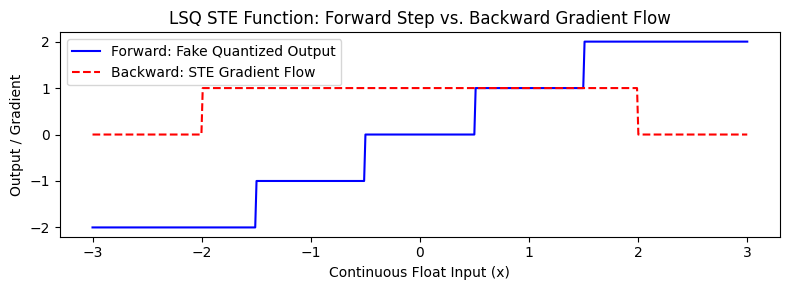

In [2]:
import matplotlib.pyplot as plt
import torch

# Define inputs across continuous real range
x = torch.linspace(-3.0, 3.0, 500, requires_grad=True)
scale = torch.tensor([1.0])

# Forward Pass
y_quant = STEQuantize.apply(x, scale, -2, 2)
loss = y_quant.sum()
loss.backward()

# Plot Forward Quantization Step + Backward Gradient Flow
plt.figure(figsize=(8, 3))
plt.plot(x.detach().numpy(), y_quant.detach().numpy(), label="Forward: Fake Quantized Output", color="blue")
plt.plot(x.detach().numpy(), x.grad.numpy(), label="Backward: STE Gradient Flow", color="red", linestyle="--")
plt.xlabel("Continuous Float Input (x)")
plt.ylabel("Output / Gradient")
plt.legend()
plt.title("LSQ STE Function: Forward Step vs. Backward Gradient Flow")
plt.tight_layout()
plt.savefig("qat_ste_gradient_flow.png")
print("Diagnostic plot saved to qat_ste_gradient_flow.png")